# Modelo JoinPoint (Borrador)

In [1]:
# [Librerías Importadas]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
from sklearn.model_selection import train_test_split
import pwlf


In [2]:
df = pd.read_csv("C:\Dengue_caracterization\DATA_LAST\Datos Modelos\datos_completos.csv")
print(df.head())

  municipio   año  periodo  casos  ciclo_vital_adolescencia  \
0   BARANOA  2018        2      1                       1.0   
1   BARANOA  2018        4      1                       0.0   
2   BARANOA  2018        5      1                       0.0   
3   BARANOA  2018        6      2                       0.0   
4   BARANOA  2018        7      3                       0.0   

   ciclo_vital_adulto  ciclo_vital_adulto_mayor  ciclo_vital_infante_mayor  \
0            0.000000                       0.0                   0.000000   
1            1.000000                       0.0                   0.000000   
2            1.000000                       0.0                   0.000000   
3            1.000000                       0.0                   0.000000   
4            0.333333                       0.0                   0.666667   

   ciclo_vital_infante_menor  regimen_salud_contributivo  ...  sexo_femenino  \
0                        0.0                         1.0  ...       1.00

## Correlación y Colinealidad

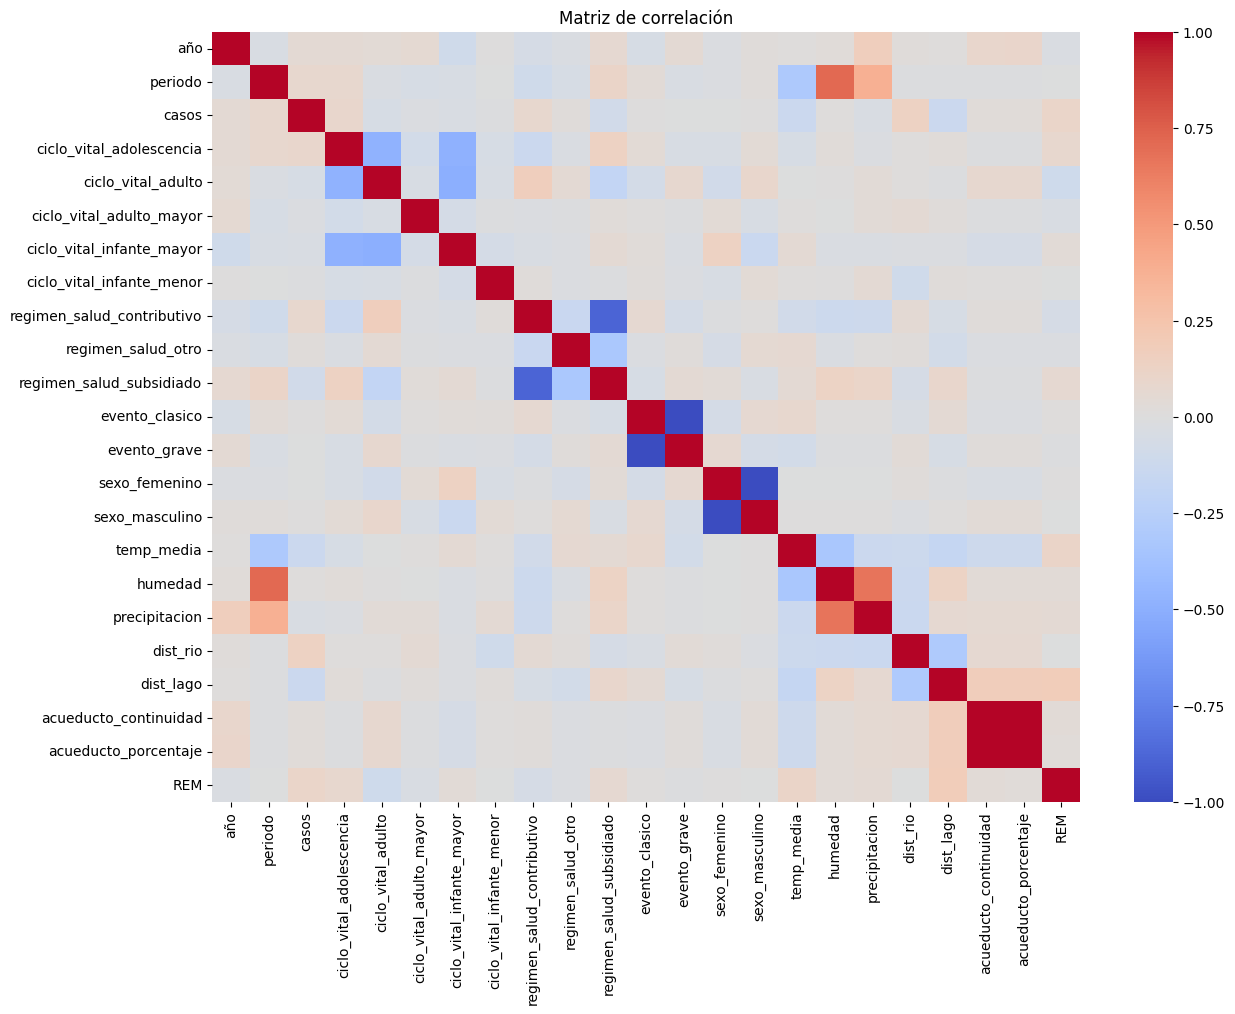

REM                           1.000000
dist_lago                     0.180336
temp_media                    0.110604
casos                         0.107502
ciclo_vital_adolescencia      0.084204
regimen_salud_subsidiado      0.063856
precipitacion                 0.049492
humedad                       0.037980
ciclo_vital_infante_mayor     0.032355
acueducto_continuidad         0.031973
acueducto_porcentaje          0.031151
evento_clasico                0.014389
sexo_femenino                 0.002430
periodo                      -0.000510
sexo_masculino               -0.002430
dist_rio                     -0.002625
ciclo_vital_infante_menor    -0.004674
evento_grave                 -0.014389
regimen_salud_otro           -0.017170
año                          -0.025323
ciclo_vital_adulto_mayor     -0.034195
regimen_salud_contributivo   -0.058547
ciclo_vital_adulto           -0.108846
Name: REM, dtype: float64


In [3]:
# [Correlación entre Variables]

# Nos quedamos solo con variables numéricas
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Correlación
corr = num_cols.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de correlación")
plt.show()

# Correlaciones respecto a REM
corr_REM = corr['REM'].sort_values(ascending=False)
print(corr_REM)

In [9]:
# Variables predictoras (excluir REM y variables categóricas como municipio)
df_vif = df.drop(columns=['REM', 'municipio','año','periodo'])

# Dataset limpio de NaN
df_vif = df_vif.dropna()

# Calcular VIF
vif = pd.DataFrame()
vif["variable"] = df_vif.columns
vif["VIF"] = [variance_inflation_factor(df_vif.values, i)
              for i in range(df_vif.shape[1])]

display(vif.sort_values(by="VIF", ascending=False))

c:\Users\TAWTOCA\anaconda3\envs\machine\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variable,VIF
0,casos,inf
1,ciclo_vital_adolescencia,inf
2,ciclo_vital_adulto,inf
3,ciclo_vital_adulto_mayor,inf
4,ciclo_vital_infante_mayor,inf
5,ciclo_vital_infante_menor,inf
6,regimen_salud_contributivo,inf
7,regimen_salud_otro,inf
8,regimen_salud_subsidiado,inf
9,evento_clasico,inf


## Prueba Modelo